# Random Forest (RF)
Random Forest is een ensemble-leermethode die gebruikmaakt van meerdere decision trees om de nauwkeurigheid en robuustheid van voorspellingen te verbeteren. In plaats van te vertrouwen op een enkele decision tree, bouwt Random Forest een "bos" van decision trees, waarbij elke boom wordt getraind op een willekeurige subset van de data en een willekeurige subset van de features. Bij het maken van voorspellingen neemt het model de meerderheid van de stemmen (voor classificatie) of het gemiddelde (voor regressie) van alle bomen in het bos. Deze aanpak vermindert de kans op overfitting en verbetert de algehele prestaties van het model, vooral bij complexe datasets met veel variabelen.

![Voorbeeld Random Forest](../assets/images/random_forest_voorbeeld.png)

Bron: `https://williamkoehrsen.medium.com/random-forest-simple-explanation-377895a60d2d`

In [1]:
# Import required libraries for Random Forest analysis
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
from utils.libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from utils.baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report
from utils.normalization_functions import Normalizer
from utils.pca_analysis_functions import PCAAnalyzer, quick_pca_analysis
from utils.lda_analysis_functions import quick_lda_analysis
from utils.measure_model_details import calculate_tree_memory_usage

In [2]:
df = pd.read_csv('../data/csv/processed_data.csv')

In [3]:
Preprocessor = LibsDataPreprocessor()
X_train, X_test, y_train_encoded, y_test_encoded, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(df) 

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 8004)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 8004)
Test dataset shape: (10291, 8004)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 8001 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 8001)
Test features shape: (10291, 8001)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]


# Comprehensive Random Forest Analysis
In deze sectie voeren we een uitgebreide Random Forest analyse uit, vergelijkbaar met onze KNN en Decision Tree analyses. We testen verschillende configuraties en vergelijken de prestaties met en zonder dimensionaliteitsreductie.

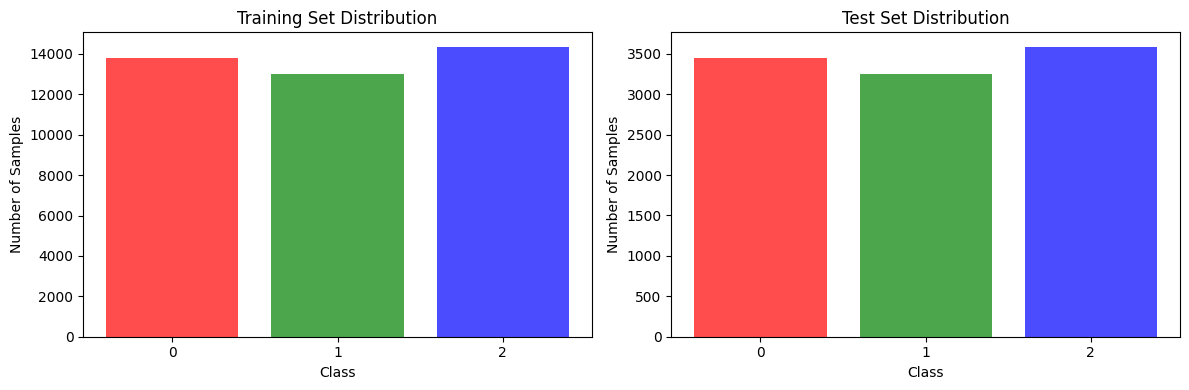


Label encoder mapping:
  innerliner → 0
  sidewall → 1
  tread → 2


In [4]:
# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train_encoded, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(train_unique)

# Test set distribution  
test_unique, test_counts = np.unique(y_test_encoded, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(test_unique)

plt.tight_layout()
plt.show()

print(f"\nLabel encoder mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} → {i}")

In [5]:
# Remove wavelengths from df that are not in NIST top 50% data
print("=" * 70)
print("FILTERING DF TO ONLY INCLUDE NIST TOP 50% WAVELENGTHS")
print("=" * 70)

# Load NIST top 50% wavelengths
nist_top_50_percent_df = pd.read_csv('../data/csv/nist_top_50_percent_wavelengths.csv')

# Extract all unique wavelengths from nist_top_50_percent_df
nist_wavelengths_set = set()
for column in nist_top_50_percent_df.columns:
    # Get wavelengths from this element column, drop NaN values
    element_wavelengths = nist_top_50_percent_df[column].dropna().tolist()
    nist_wavelengths_set.update([float(wl) for wl in element_wavelengths if pd.notna(wl)])

print(f"NIST wavelengths found: {len(nist_wavelengths_set)} unique wavelengths")
print(f"NIST wavelength range: {min(nist_wavelengths_set):.1f} - {max(nist_wavelengths_set):.1f} nm")

# Get wavelength columns from df (exclude metadata columns)
metadata_columns = ['tire_number', 'origin', 'measurement_id']
all_wavelength_columns = [col for col in df.columns if col not in metadata_columns]

print(f"\nOriginal df wavelengths: {len(all_wavelength_columns)}")
print(f"Original df wavelength range: {min([float(col) for col in all_wavelength_columns]):.1f} - {max([float(col) for col in all_wavelength_columns]):.1f} nm")

# Find wavelengths to keep (with tolerance for matching)
tolerance = 0.1  # 0.1 nm tolerance
wavelengths_to_keep = []

for col in all_wavelength_columns:
    col_wl = float(col)
    # Check if this wavelength is close to any NIST wavelength
    for nist_wl in nist_wavelengths_set:
        if abs(col_wl - nist_wl) <= tolerance:
            wavelengths_to_keep.append(col)
            break

print(f"\nWavelengths to keep: {len(wavelengths_to_keep)}")
print(f"Wavelengths to remove: {len(all_wavelength_columns) - len(wavelengths_to_keep)}")
print(f"Reduction: {((len(all_wavelength_columns) - len(wavelengths_to_keep)) / len(all_wavelength_columns)) * 100:.1f}%")

# Create filtered dataframe
columns_to_keep = metadata_columns + wavelengths_to_keep
df_filtered = df[columns_to_keep].copy()

print(f"\n✅ Filtered DataFrame created:")
print(f"   Original shape: {df.shape}")
print(f"   Filtered shape: {df_filtered.shape}")
print(f"   Columns removed: {df.shape[1] - df_filtered.shape[1]}")

# Show some examples of kept wavelengths
print(f"\nFirst 10 wavelengths kept:")
for i, wl in enumerate(wavelengths_to_keep[:10]):
    print(f"   {wl} nm")

if len(wavelengths_to_keep) > 10:
    print(f"   ... and {len(wavelengths_to_keep) - 10} more")

# Update the df variable to the filtered version
nist_filtered_df = df_filtered.copy()

print(f"\n🎯 df has been updated to only contain NIST top 50% wavelengths")
print(f"   New df shape: {nist_filtered_df.shape}")

FILTERING DF TO ONLY INCLUDE NIST TOP 50% WAVELENGTHS
NIST wavelengths found: 347 unique wavelengths
NIST wavelength range: 202.4 - 939.7 nm

Original df wavelengths: 8001
Original df wavelength range: 200.0 - 1000.0 nm

Wavelengths to keep: 377
Wavelengths to remove: 7624
Reduction: 95.3%

✅ Filtered DataFrame created:
   Original shape: (51453, 8004)
   Filtered shape: (51453, 380)
   Columns removed: 7624

First 10 wavelengths kept:
   202.3 nm
   202.4 nm
   202.5 nm
   202.6 nm
   202.7 nm
   206.1 nm
   206.2 nm
   212.3 nm
   212.4 nm
   212.5 nm
   ... and 367 more

🎯 df has been updated to only contain NIST top 50% wavelengths
   New df shape: (51453, 380)


In [6]:
nist_X_train, nist_X_test, nist_y_train_encoded, nist_y_test_encoded, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(nist_filtered_df) 

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 380)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 380)
Test dataset shape: (10291, 380)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 377 wavelength columns
Extracting features and targets from training set...
Extracting features and targets from test set...
Converting features to numeric...
Encoding labels...

Final results:
Training features shape: (41162, 377)
Test features shape: (10291, 377)
Label classes: ['innerliner' 'sidewall' 'tread']
Training label distribution: [13808 13005 14349]
Test label distribution: [3452 3252 3587]


In [7]:
# Convert column names to wavelengths and filter
wavelength_values = [float(col) for col in X_train.columns]
selected_indices = []
selected_wavelengths = []

for i, wl in enumerate(wavelength_values):
    if (670 <= wl <= 750) or (950 <= wl <= 960):
        selected_indices.append(i)
        selected_wavelengths.append(wl)

# Create filtered datasets from subset
X_train_ig = X_train.iloc[:, selected_indices]
X_test_ig = X_test.iloc[:, selected_indices]

## 1. Random Forest op met Information Gain bepaalde meest discriminatieve Features

In [8]:
# Import additional libraries for comprehensive testing
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import time
import tracemalloc
import gc

# Add the measure_model_details import
from utils.measure_model_details import (
    measure_training_time, measure_inference_time, get_memory_usage,
    comprehensive_model_analysis, print_training_report, print_inference_performance
)

def comprehensive_decision_tree_evaluation():
    """
    Comprehensive Decision Tree evaluation across 4 different feature sets:
    1. PCA reduced features
    2. LDA reduced features  
    3. Information Gain selected wavelengths
    4. NIST emission line selected features
    """
    
    print("=" * 80)
    print("COMPREHENSIVE RANDOM FOREST EVALUATION")
    print("=" * 80)
    
    # Initialize results storage
    evaluation_results = {}
    
    # Common hyperparameter grid for all tests
    param_grid = {
    'n_estimators': [100],
    'max_depth': [30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
    }
    
    print(f"Parameter grid size: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['max_features']) * len(param_grid['bootstrap'])} combinations")
    print(f"Cross-validation folds: 2")
    print()
    
    return param_grid, evaluation_results

def evaluate_random_forest_configuration(X_train, X_test, y_train, y_test, 
                                        config_name, param_grid, label_encoder,
                                        n_runs=3):
    """
    Evaluate a single Decision Tree configuration with comprehensive metrics.
    
    Parameters:
    -----------
    X_train, X_test : array-like
        Training and test features
    y_train, y_test : array-like
        Training and test labels
    config_name : str
        Name of the configuration being tested
    param_grid : dict
        Hyperparameter grid for GridSearchCV
    label_encoder : LabelEncoder
        Label encoder for classification reports
    n_runs : int, default=3
        Number of runs for timing measurements
        
    Returns:
    --------
    dict : Comprehensive evaluation results
    """
    
    print(f"\n{'='*60}")
    print(f"EVALUATING: {config_name.upper()}")
    print(f"{'='*60}")
    print(f"Training shape: {X_train.shape}")
    print(f"Test shape: {X_test.shape}")
    
    # Track memory usage
    tracemalloc.start()
    memory_before = get_memory_usage()
    
    # 1. HYPERPARAMETER OPTIMIZATION WITH TIMING
    print(f"\n🔍 Hyperparameter Optimization...")
    
    optimization_start = time.perf_counter()
    
    rf_classifier = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(
        rf_classifier,
        param_grid,
        cv=2,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0  # Reduced verbosity
    )
    
    # Measure grid search time
    grid_search.fit(X_train, y_train)
    optimization_end = time.perf_counter()
    optimization_time = optimization_end - optimization_start
    
    best_params = grid_search.best_params_
    best_cv_score = grid_search.best_score_
    
    print(f"   Best parameters: {best_params}")
    print(f"   Best CV score: {best_cv_score:.4f}")
    print(f"   Optimization time: {optimization_time:.2f} seconds")
    
    # 2. TRAINING TIME MEASUREMENT
    print(f"\n⏱️  Training Time Measurement ({n_runs} runs)...")
    
    # Create final model with best parameters
    final_model = RandomForestClassifier(**best_params, random_state=42)
    
    # Measure training time
    training_results = measure_training_time(
        final_model, X_train, y_train, n_runs=n_runs
    )
    
    print(f"   Mean training time: {training_results['mean_time']:.4f} ± {training_results['std_time']:.4f} seconds")
    print(f"   Memory increase: {training_results['memory_increase_mean']:.2f} MB")
    
    # Use the trained model from timing measurement
    trained_model = training_results['trained_model']
    
    # 3. PREDICTION AND PERFORMANCE METRICS
    print(f"\n📊 Performance Evaluation...")
    
    # Make predictions
    y_train_pred = trained_model.predict(X_train)
    y_test_pred = trained_model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # F1 scores (macro and weighted)
    train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"   Training Accuracy: {train_accuracy:.4f}")
    print(f"   Test Accuracy: {test_accuracy:.4f}")
    print(f"   Training F1 (macro): {train_f1_macro:.4f}")
    print(f"   Test F1 (macro): {test_f1_macro:.4f}")
    print(f"   Training F1 (weighted): {train_f1_weighted:.4f}")
    print(f"   Test F1 (weighted): {test_f1_weighted:.4f}")
    
    # 4. INFERENCE TIME MEASUREMENT
    print(f"\n⚡ Inference Time Measurement...")
    
    inference_results = measure_inference_time(trained_model, X_test, n_runs=10)
    
    print(f"   Mean inference time: {inference_results['mean_time']*1000:.2f} ± {inference_results['std_time']*1000:.2f} ms")
    print(f"   Time per sample: {inference_results['mean_time']*1000/len(X_test):.4f} ms")
    print(f"   Samples per second: {len(X_test)/inference_results['mean_time']:.0f}")
    
    # 5. MEMORY USAGE ANALYSIS
    memory_after = get_memory_usage()
    memory_peak = tracemalloc.get_traced_memory()[1] / 1024 / 1024  # Convert to MB
    tracemalloc.stop()

    
    # 7. CLASSIFICATION REPORT
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, digits=4))
    
    # 8. CONFUSION MATRIX VISUALIZATION
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {config_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
        # 6. RANDOM FOREST MODEL CHARACTERISTICS
    print(f"\n🌲 Random Forest Characteristics...")
    print(f"   Number of trees: {trained_model.n_estimators}")
    print(f"   Number of classes: {len(trained_model.classes_)}")
    print(f"   Number of features: {X_train.shape[1]}")

    # Analyze individual trees in the forest
    tree_depths = []
    tree_leaves = []
    for estimator in trained_model.estimators_:
        tree_depths.append(estimator.get_depth())
        tree_leaves.append(estimator.get_n_leaves())

    # Calculate statistics
    mean_depth = np.mean(tree_depths)
    max_depth = np.max(tree_depths)
    min_depth = np.min(tree_depths)
    std_depth = np.std(tree_depths)

    mean_leaves = np.mean(tree_leaves)
    max_leaves = np.max(tree_leaves)
    min_leaves = np.min(tree_leaves)
    std_leaves = np.std(tree_leaves)

    print(f"   Tree depths - Mean: {mean_depth:.1f}, Max: {max_depth}, Min: {min_depth}, Std: {std_depth:.1f}")
    print(f"   Tree leaves - Mean: {mean_leaves:.1f}, Max: {max_leaves}, Min: {min_leaves}, Std: {std_leaves:.1f}")

        
    # Compile all results
    results = {
        'config_name': config_name,
        'data_shape': X_train.shape,
        'n_features': X_train.shape[1],
        
        # Hyperparameter results
        'best_params': best_params,
        'best_cv_score': best_cv_score,
        'optimization_time': optimization_time,
        
        # Performance metrics
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_f1_macro': train_f1_macro,
        'test_f1_macro': test_f1_macro,
        'train_f1_weighted': train_f1_weighted,
        'test_f1_weighted': test_f1_weighted,
        
        # Timing results
        'training_time_mean': training_results['mean_time'],
        'training_time_std': training_results['std_time'],
        'inference_time_mean': inference_results['mean_time'],
        'inference_time_std': inference_results['std_time'],
        'inference_time_per_sample': inference_results['mean_time'] / len(X_test),
        'samples_per_second': len(X_test) / inference_results['mean_time'],
        
        # Memory results
        'memory_before': memory_before,
        'memory_after': memory_after,
        'memory_increase': memory_after - memory_before,
        'memory_peak': memory_peak,
        'training_memory_increase': training_results['memory_increase_mean'],
        
        # Model characteristics - Updated for Random Forest
        'n_estimators': trained_model.n_estimators,
        'mean_tree_depth': np.mean(tree_depths),
        'max_tree_depth': np.max(tree_depths),
        'min_tree_depth': np.min(tree_depths),
        'std_tree_depth': np.std(tree_depths),
        'mean_tree_leaves': np.mean(tree_leaves),
        'max_tree_leaves': np.max(tree_leaves),
        'min_tree_leaves': np.min(tree_leaves),
        'std_tree_leaves': np.std(tree_leaves),
        # 'features_used': np.sum(importances > 0) if hasattr(trained_model, 'feature_importances_') else None,
        # 'max_importance': np.max(importances) if hasattr(trained_model, 'feature_importances_') else None,
        'oob_score': getattr(trained_model, 'oob_score_', None),
        
        # Model object
        'trained_model': trained_model,
        'predictions': y_test_pred
    }
    # Feature importance analysis
    if hasattr(trained_model, 'feature_importances_'):
        importances = trained_model.feature_importances_
        n_features_used = np.sum(importances > 0)
        max_importance = np.max(importances)
        mean_importance = np.mean(importances[importances > 0])
        
        print(f"   Features used: {n_features_used}/{len(importances)}")
        print(f"   Max feature importance: {max_importance:.6f}")
        print(f"   Mean importance (non-zero): {mean_importance:.6f}")

        # Out-of-bag score (if bootstrap=True)
        if hasattr(trained_model, 'oob_score_') and trained_model.oob_score_ is not None:
            print(f"   Out-of-bag score: {trained_model.oob_score_:.4f}")

    # Clean up memory
    gc.collect()
    
    return results

# Now run the comprehensive evaluation
param_grid, evaluation_results = comprehensive_decision_tree_evaluation()

COMPREHENSIVE RANDOM FOREST EVALUATION
Parameter grid size: 24 combinations
Cross-validation folds: 2




🚀 Starting Test 1: NIST Emission Line Features

EVALUATING: NIST EMISSION LINES
Training shape: (41162, 377)
Test shape: (10291, 377)

🔍 Hyperparameter Optimization...
   Best parameters: {'bootstrap': False, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
   Best CV score: 0.8235
   Optimization time: 2297.57 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 146.4793 ± 0.1560 seconds
   Memory increase: 39.55 MB

📊 Performance Evaluation...
   Training Accuracy: 1.0000
   Test Accuracy: 0.8395
   Training F1 (macro): 1.0000
   Test F1 (macro): 0.8381
   Training F1 (weighted): 1.0000
   Test F1 (weighted): 0.8390

⚡ Inference Time Measurement...
   Mean inference time: 299.34 ± 5.48 ms
   Time per sample: 0.0291 ms
   Samples per second: 34379

📋 Classification Report:
              precision    recall  f1-score   support

  innerliner     0.8375    0.8633    0.8502      3452
    sidewall     0.8365 

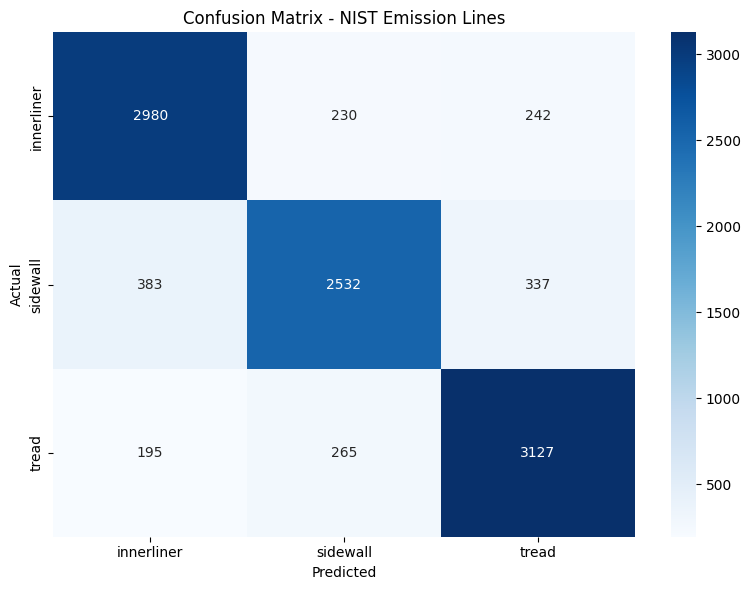


🌲 Random Forest Characteristics...
   Number of trees: 100
   Number of classes: 3
   Number of features: 377
   Tree depths - Mean: 30.0, Max: 30, Min: 29, Std: 0.1
   Tree leaves - Mean: 4765.5, Max: 4970, Min: 4571, Std: 71.0
   Features used: 377/377
   Max feature importance: 0.049892
   Mean importance (non-zero): 0.002653


In [9]:
#Test 1: NIST Emission Line Features
print("\n🚀 Starting Test 1: NIST Emission Line Features")
nist_results = evaluate_random_forest_configuration(
    nist_X_train, nist_X_test, nist_y_train_encoded, nist_y_test_encoded,
    "NIST Emission Lines", param_grid, label_encoder
)
evaluation_results['NIST'] = nist_results


🚀 Starting Test 2: Information Gain Selected Features

EVALUATING: INFORMATION GAIN SELECTION
Training shape: (41162, 902)
Test shape: (10291, 902)

🔍 Hyperparameter Optimization...
   Best parameters: {'bootstrap': False, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
   Best CV score: 0.8969
   Optimization time: 5542.66 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 238.8608 ± 0.0469 seconds
   Memory increase: 20.67 MB

📊 Performance Evaluation...
   Training Accuracy: 1.0000
   Test Accuracy: 0.9124
   Training F1 (macro): 1.0000
   Test F1 (macro): 0.9123
   Training F1 (weighted): 1.0000
   Test F1 (weighted): 0.9125

⚡ Inference Time Measurement...
   Mean inference time: 433.71 ± 3.41 ms
   Time per sample: 0.0421 ms
   Samples per second: 23728

📋 Classification Report:
              precision    recall  f1-score   support

  innerliner     0.9311    0.9163    0.9236      3452
    sidewa

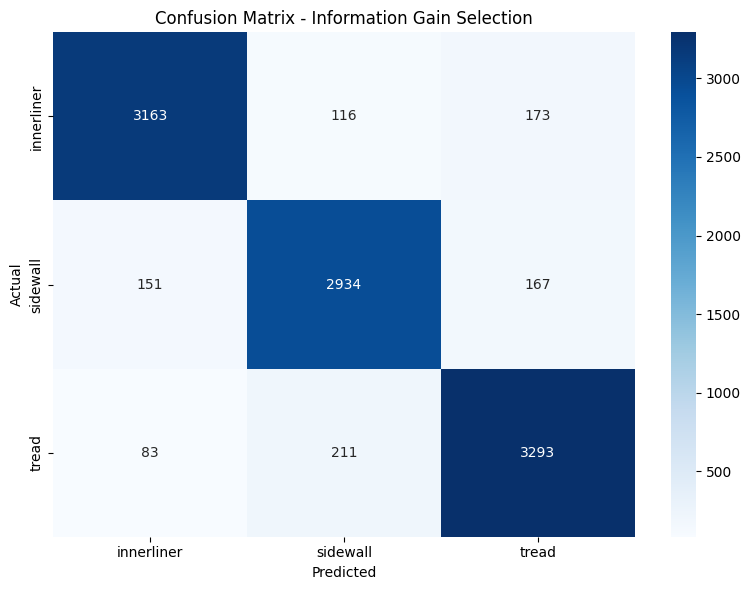


🌲 Random Forest Characteristics...
   Number of trees: 100
   Number of classes: 3
   Number of features: 902
   Tree depths - Mean: 30.0, Max: 30, Min: 28, Std: 0.2
   Tree leaves - Mean: 3526.0, Max: 3675, Min: 3317, Std: 75.2
   Features used: 902/902
   Max feature importance: 0.017297
   Mean importance (non-zero): 0.001109


In [10]:
# Test 2: Information Gain Selected Features  
print("\n🚀 Starting Test 2: Information Gain Selected Features")
ig_results = evaluate_random_forest_configuration(
    X_train_ig, X_test_ig, y_train_encoded, y_test_encoded,
    "Information Gain Selection", param_grid, label_encoder
)
evaluation_results['Information_Gain'] = ig_results


🚀 Starting Test 3: PCA Analysis

EVALUATING: PCA
Training shape: (41162, 18)
Test shape: (10291, 18)

🔍 Hyperparameter Optimization...
   Best parameters: {'bootstrap': False, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
   Best CV score: 0.9439
   Optimization time: 147.85 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 28.7151 ± 0.0256 seconds
   Memory increase: 20.12 MB

📊 Performance Evaluation...
   Training Accuracy: 1.0000
   Test Accuracy: 0.9591
   Training F1 (macro): 1.0000
   Test F1 (macro): 0.9590
   Training F1 (weighted): 1.0000
   Test F1 (weighted): 0.9591

⚡ Inference Time Measurement...
   Mean inference time: 144.46 ± 0.39 ms
   Time per sample: 0.0140 ms
   Samples per second: 71236

📋 Classification Report:
              precision    recall  f1-score   support

  innerliner     0.9686    0.9728    0.9707      3452
    sidewall     0.9547    0.9471    0.9509      3252
     

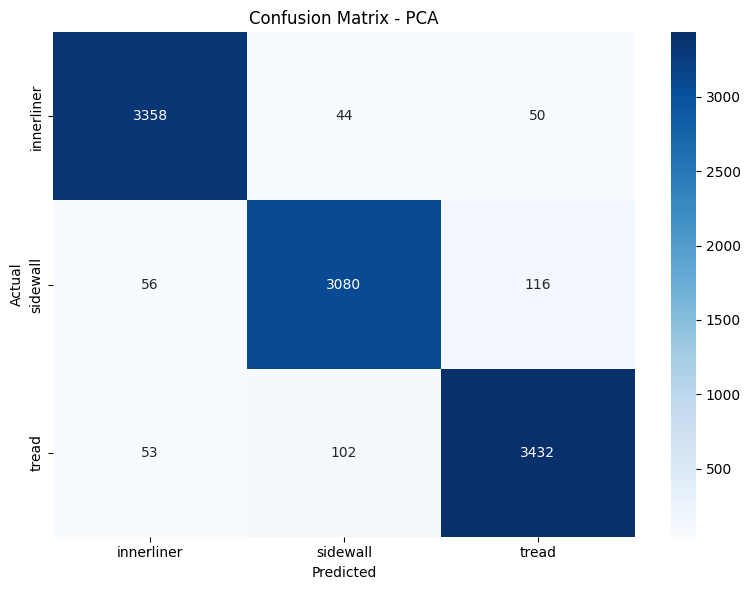


🌲 Random Forest Characteristics...
   Number of trees: 100
   Number of classes: 3
   Number of features: 18
   Tree depths - Mean: 28.5, Max: 30, Min: 25, Std: 1.4
   Tree leaves - Mean: 3996.5, Max: 4192, Min: 3754, Std: 91.4
   Features used: 18/18
   Max feature importance: 0.126422
   Mean importance (non-zero): 0.055556


In [11]:
print("\n🚀 Starting Test 3: PCA Analysis")

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=18) # n_components chosen based on prior analysis (95% variance)
X_train_pca = pca.fit_transform(X_train, y_train_encoded)
X_test_pca = pca.transform(X_test)

pca_result = evaluate_random_forest_configuration(
    X_train_pca, X_test_pca, y_train_encoded, y_test_encoded,
    config_name='PCA', label_encoder=label_encoder, param_grid=param_grid)


EVALUATING: LDA
Training shape: (41162, 2)
Test shape: (10291, 2)

🔍 Hyperparameter Optimization...
   Best parameters: {'bootstrap': True, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
   Best CV score: 0.9757
   Optimization time: 22.22 seconds

⏱️  Training Time Measurement (3 runs)...
   Mean training time: 4.6791 ± 0.0459 seconds
   Memory increase: 4.80 MB

📊 Performance Evaluation...
   Training Accuracy: 0.9893
   Test Accuracy: 0.9226
   Training F1 (macro): 0.9892
   Test F1 (macro): 0.9219
   Training F1 (weighted): 0.9893
   Test F1 (weighted): 0.9224

⚡ Inference Time Measurement...
   Mean inference time: 78.25 ± 0.57 ms
   Time per sample: 0.0076 ms
   Samples per second: 131519

📋 Classification Report:
              precision    recall  f1-score   support

  innerliner     0.9324    0.9464    0.9393      3452
    sidewall     0.9100    0.8865    0.8981      3252
       tread     0.9240    0.9323    0.9281 

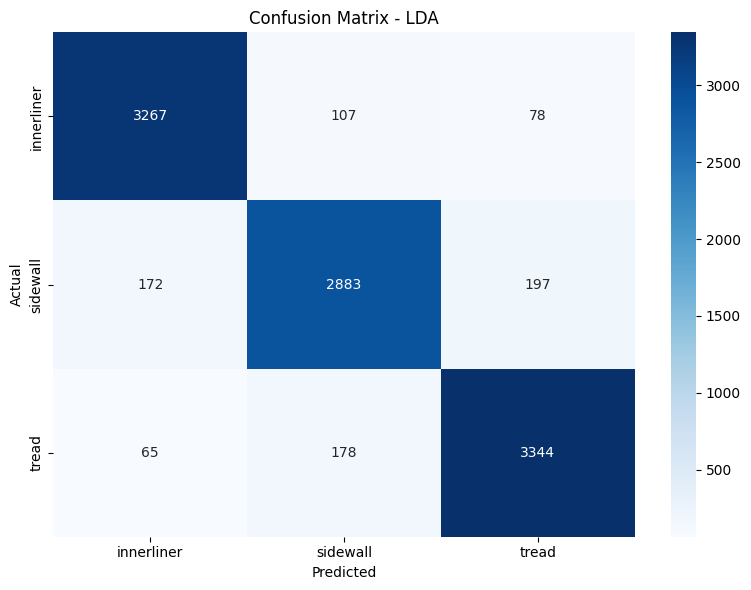


🌲 Random Forest Characteristics...
   Number of trees: 100
   Number of classes: 3
   Number of features: 2
   Tree depths - Mean: 22.9, Max: 30, Min: 18, Std: 2.4
   Tree leaves - Mean: 657.1, Max: 694, Min: 613, Std: 17.3
   Features used: 2/2
   Max feature importance: 0.500397
   Mean importance (non-zero): 0.500000


In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)  # n_components chosen based on prior analysis

X_train_lda = lda.fit_transform(X_train, y_train_encoded)
X_test_lda = lda.transform(X_test)

lda_result = evaluate_random_forest_configuration(
	X_train_lda, X_test_lda, y_train_encoded, y_test_encoded,
	config_name="LDA", label_encoder=label_encoder, param_grid=param_grid
)

COMPREHENSIVE KNN RESULTS COMPARISON
⚠️  Could not extract PCA results
⚠️  Could not extract LDA results

KNN PERFORMANCE SUMMARY:
                    Method  Test_Accuracy  Features  training_time_mean  inference_time_per_sample  memory_peak k_neighbors
       NIST Emission Lines       0.839471       377          146.479341                   0.000029   246.445691         N/A
Information Gain Selection       0.912448       902          238.860812                   0.000042   574.739035         N/A


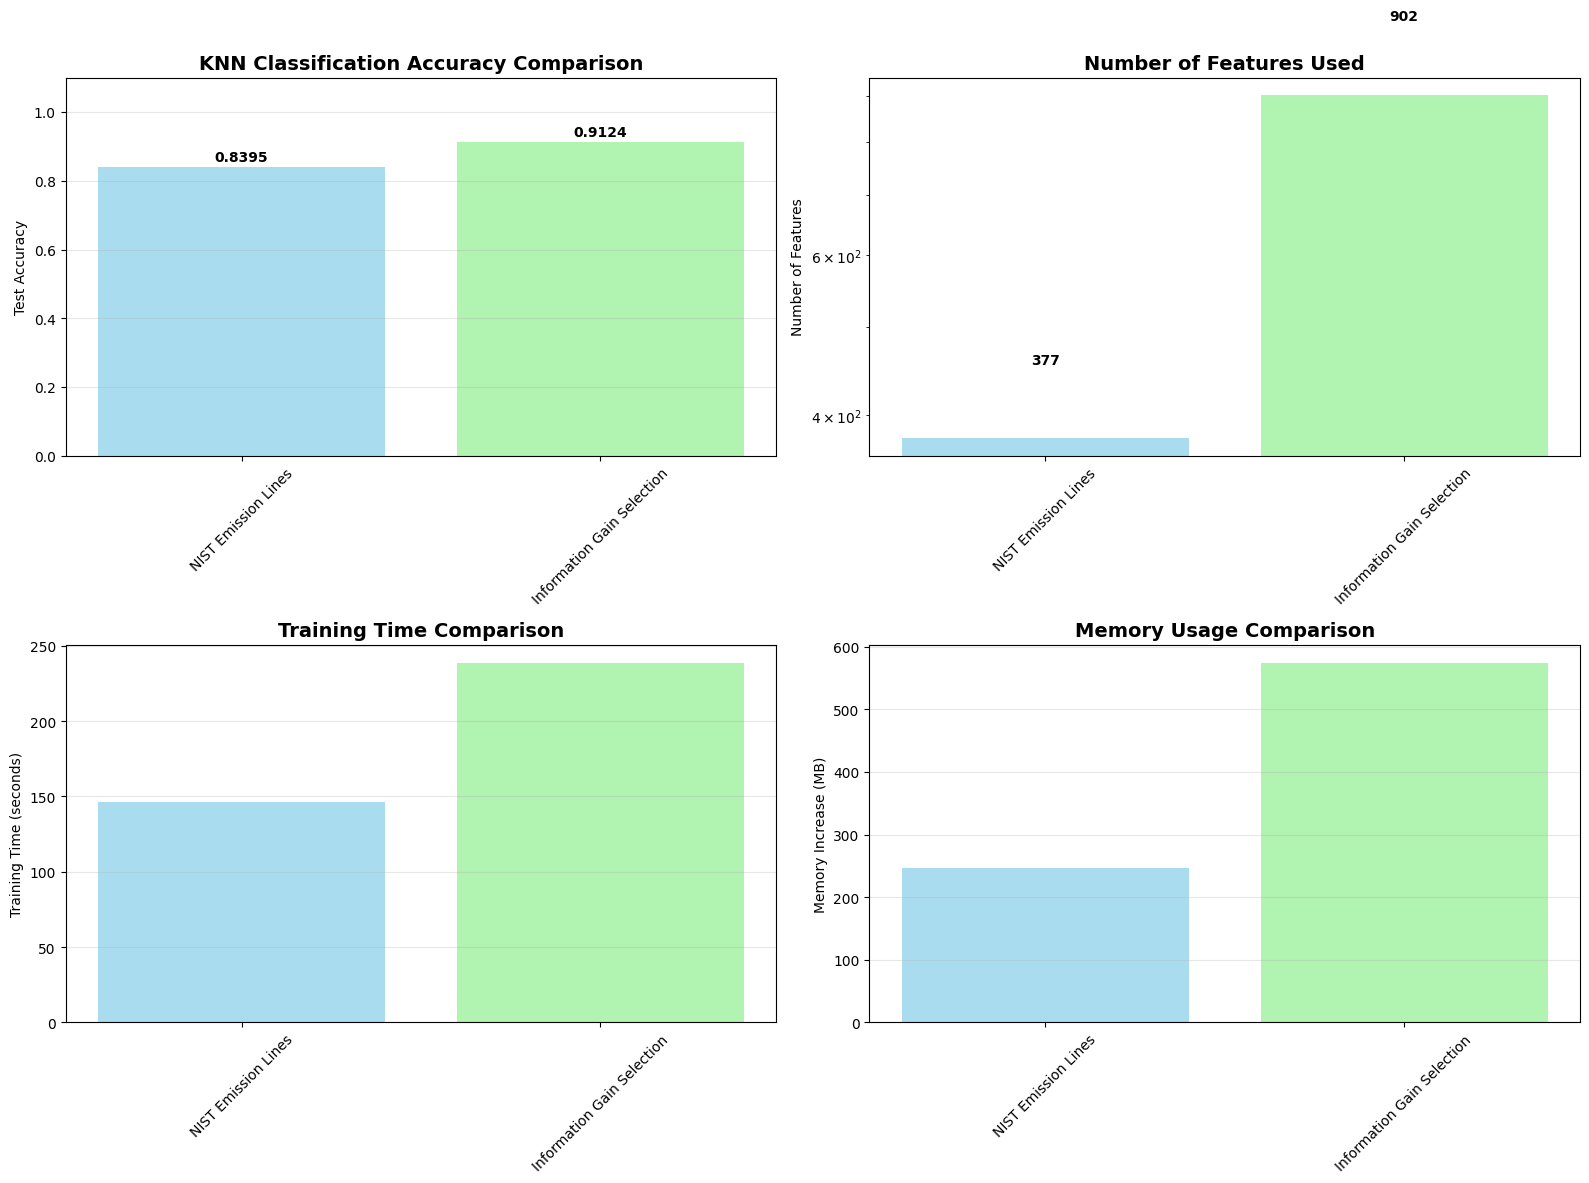

In [ ]:
# Comprehensive Results Comparison
print("=" * 80)
print("COMPREHENSIVE KNN RESULTS COMPARISON")
print("=" * 80)

# Extract results from PCA and LDA analyses
try:
    evaluation_results['PCA'] = {
        'config_name': f'PCA (18 components)',
        'test_accuracy': pca_result['test_f1_weighted'],
        'n_features': 18,
        'training_time_mean': pca_result['training_time_mean'],
        'inference_time_per_sample': pca_result['inference_time_per_sample'],
        'memory_peak': pca_result['memory_peak'],
    }
except:
    print("⚠️  Could not extract PCA results")

try:
        evaluation_results['LDA'] = {
            'config_name': f'LDA (2 components)',
            'test_accuracy': lda_result['test_f1_weighted'],
            'n_features': 2,
            'training_time_mean': lda_result['training_time_mean'],
            'inference_time_per_sample': lda_result['inference_time_per_sample'],
            'memory_peak': lda_result['memory_peak'],
        }
except:
    print("⚠️  Could not extract LDA results")

# Create summary table
summary_data = []
for method_name, results in evaluation_results.items():
    if isinstance(results, dict) and 'test_accuracy' in results:
        summary_data.append({
            'Method': results.get('config_name', method_name),
            'Test_Accuracy': results['test_accuracy'],
            'Features': results['n_features'],
            'training_time_mean': results.get('training_time_mean', 'N/A'),
            'inference_time_per_sample': results.get('inference_time_per_sample', 'N/A'),
            'memory_peak': results.get('memory_peak', 'N/A'),
        })

if summary_data:
    results_df = pd.DataFrame(summary_data)
    print("\nKNN PERFORMANCE SUMMARY:")
    print("=" * 120)
    print(results_df.to_string(index=False))
    print("=" * 120)
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    methods = results_df['Method']
    accuracies = results_df['Test_Accuracy']
    features = results_df['Features']
    
    # 1. Accuracy comparison
    colors = ['skyblue', 'lightgreen', 'orange', 'pink'][:len(methods)]
    bars1 = ax1.bar(methods, accuracies, color=colors, alpha=0.7)
    ax1.set_title('KNN Classification Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Test Accuracy')
    ax1.set_ylim(0, 1.1)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    for bar, accuracy in zip(bars1, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Feature count comparison
    bars2 = ax2.bar(methods, features, color=colors, alpha=0.7)
    ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Features')
    ax2.set_yscale('log')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    for bar, feature_count in zip(bars2, features):
        ax2.text(bar.get_x() + bar.get_width()/2, feature_count * 1.2,
                 f'{feature_count}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Training time comparison (if available)
    training_times = [results_df['training_time_mean'].iloc[i] if results_df['training_time_mean'].iloc[i] != 'N/A' else 0 
                     for i in range(len(methods))]
    if any(t > 0 for t in training_times):
        bars3 = ax3.bar(methods, training_times, color=colors, alpha=0.7)
        ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Training Time (seconds)')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'Training time data\nnot available', 
                transform=ax3.transAxes, ha='center', va='center', fontsize=12)
        ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
    
    # 4. Memory usage comparison (if available)
    memory_usage = [results_df['memory_peak'].iloc[i] if results_df['memory_peak'].iloc[i] != 'N/A' else 0 
                   for i in range(len(methods))]
    if any(m > 0 for m in memory_usage):
        bars4 = ax4.bar(methods, memory_usage, color=colors, alpha=0.7)
        ax4.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
        ax4.set_ylabel('Memory Increase (MB)')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Memory usage data\nnot available', 
                transform=ax4.transAxes, ha='center', va='center', fontsize=12)
        ax4.set_title('Memory Usage Comparison', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()